In [1]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt

from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [2]:
VIDEO_PATH = r'data/Videos/'
LANDMARK_PATH = r'landmarks/'
PROCESSED_LANDMARK_PATH = r'landmarks_processed/'
MODEL_SAVE_PATH = r'models/saved/'
REPORT_PATH = r'VideoReport_updated.csv'
FIG_SAVE_PATH = r'plots/'

TARGET_FRAMES = 172
TARGET_FPS = 15

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
os.makedirs(FIG_SAVE_PATH, exist_ok=True)

In [3]:
BATCH_SIZE  = 32
VAL_SPLIT   = 0.15
NUM_WORKERS = 0 #windows 
SEED        = 42

In [4]:
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


## Skeleton Dataset & Loading


In [5]:
class SkeletonDataset(Dataset):
    
    def __init__(self, root: str) -> None:
        self.samples: list[tuple[str, int]] = []
        self.classes: list[str] = sorted(
            d for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d))
        )
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        for cls in self.classes:
            cls_dir = os.path.join(root, cls)
            for fname in os.listdir(cls_dir):
                if fname.endswith(".npy"):
                    self.samples.append(
                        (os.path.join(cls_dir, fname), self.class_to_idx[cls])
                    )

        print(f"  Dataset: {len(self.samples)} clips, {len(self.classes)} classes")
        print(f"  Classes: {self.classes}")

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        path, label = self.samples[idx]
        arr = np.load(path).astype(np.float32)#(172, 59, 3)
        arr = arr[:, :, :2] # remove conf 

        vel = np.zeros_like(arr)
        vel[1:] = arr[1:] - arr[:-1]
        arr = np.concatenate([arr, vel], axis=-1)

        #normalization
        pos = arr[:, :, :2]
        mu  = pos.mean(axis=(0, 1), keepdims=True)
        std = pos.std(axis=(0, 1), keepdims=True) + 1e-6
        arr[:, :, :2] = (pos - mu) / std

        seq = arr.reshape(172, -1)

        return torch.from_numpy(seq), torch.tensor(label, dtype=torch.long)

In [6]:
full_dataset = SkeletonDataset(PROCESSED_LANDMARK_PATH)
NUM_CLASSES  = len(full_dataset.classes)

try:
    _report_n = pd.read_csv(REPORT_PATH).shape[0]
    print(f"Clips listed in {REPORT_PATH}      : {_report_n}")
except Exception as e:
    print(f"Could not read {REPORT_PATH}: {e}")
print(f"Clips actually usable (processed landmarks): {len(full_dataset)}")
if 'reports_n' not in dir() and '_report_n' in dir():
    _dropped = _report_n - len(full_dataset)
    if _dropped > 0:
        print(f"  -> {_dropped} clip(s) dropped during filtering / landmark QC "
              f"(low pose confidence, missing hands, etc.)")


# described in the paper's Training Protocol (Sec. 4.7).
all_indices = list(range(len(full_dataset)))
all_labels_list = [full_dataset.samples[i][1] for i in all_indices]

train_idx, val_idx = train_test_split(
    all_indices,
    test_size=VAL_SPLIT,
    stratify=all_labels_list,
    random_state=SEED,
)

train_ds = torch.utils.data.Subset(full_dataset, train_idx)
val_ds   = torch.utils.data.Subset(full_dataset, val_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=True, drop_last=True)

val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True)

print(f"\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Train clips: {len(train_ds)} | Val clips: {len(val_ds)}")

all_labels = torch.tensor([full_dataset.samples[i][1] for i in range(len(full_dataset))])
class_counts  = torch.bincount(all_labels, minlength=NUM_CLASSES).float()
class_weights = (class_counts.sum() / (NUM_CLASSES * class_counts)).clamp(max=10.0)
print(f"Class weights: {class_weights.tolist()}")


  Dataset: 535 clips, 26 classes
  Classes: ['1-Ardhpatka', '10-Katakamukha', '11-Suchi', '12-Chandrakala', '13-Padmakosh', '14-Sarpashirsha', '15-Mrigashirsha', '16-Simhamukha', '17-Kangula', '18-Alapadma', '19-Chatura', '2-Kartarimukh', '20-Bhramara', '21-Hamsasya', '22-Hamsapkshaka', '23-Sandamsha', '24-Mukula', '25-Taamrachuda', '26-Trishula', '3-Mayura', '4-Aardhchandra', '5-Aarala', '6-Shukatundaka', '7-Mushti', '8-Shikara', '9-Kapitha']
Clips listed in VideoReport_updated.csv      : 538
Clips actually usable (processed landmarks): 535
  -> 3 clip(s) dropped during filtering / landmark QC (low pose confidence, missing hands, etc.)

Train batches: 14 | Val batches: 3
Number of Classes: 26
Train clips: 454 | Val clips: 81
Class weights: [0.6858974099159241, 1.1431623697280884, 1.1431623697280884, 1.1431623697280884, 0.709549069404602, 1.4697802066802979, 1.1431623697280884, 1.1431623697280884, 1.2104072570800781, 1.1431623697280884, 1.286057710647583, 0.8573718070983887, 0.85737180

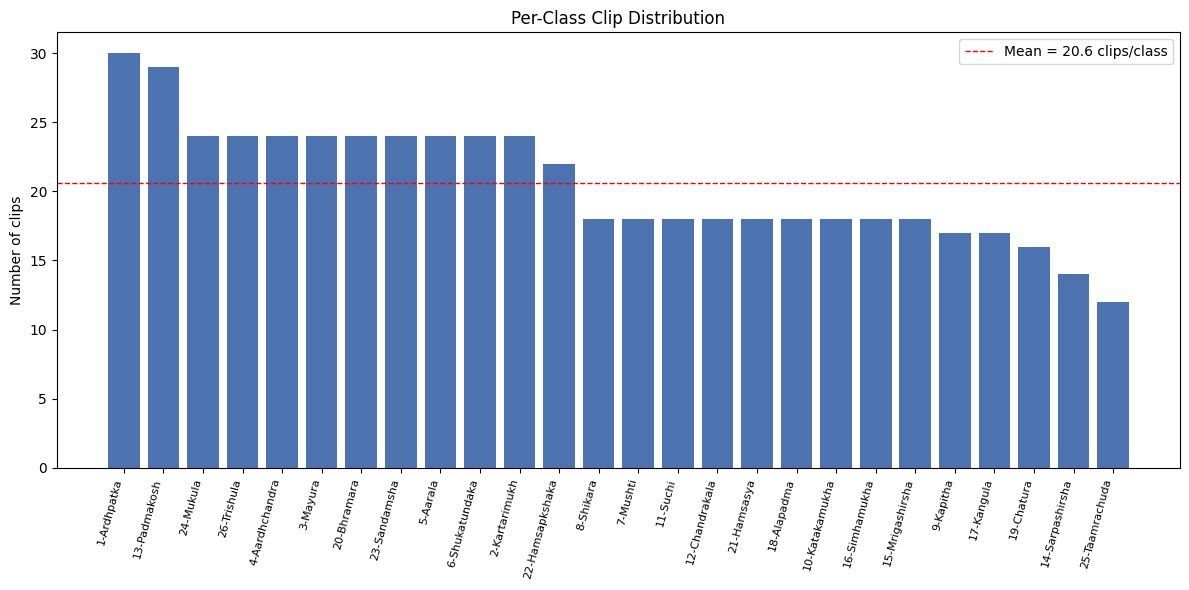

Min clips/class: 12  (25-Taamrachuda)
Max clips/class: 30  (1-Ardhpatka)


In [7]:
class_names = full_dataset.classes
counts_per_class = class_counts.numpy().astype(int)

order = np.argsort(counts_per_class)[::-1]
sorted_names  = [class_names[i] for i in order]
sorted_counts = counts_per_class[order]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(sorted_names)), sorted_counts, color="#4C72B0")
ax.axhline(sorted_counts.mean(), color="red", linestyle="--", linewidth=1,
           label=f"Mean = {sorted_counts.mean():.1f} clips/class")
ax.set_xticks(range(len(sorted_names)))
ax.set_xticklabels(sorted_names, rotation=75, ha="right", fontsize=8)
ax.set_ylabel("Number of clips")
ax.set_title("Per-Class Clip Distribution")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_SAVE_PATH, "class_distribution.png"), dpi=200)
plt.show()

print(f"Min clips/class: {sorted_counts.min()}  ({sorted_names[sorted_counts.argmin()]})")
print(f"Max clips/class: {sorted_counts.max()}  ({sorted_names[sorted_counts.argmax()]})")


## TCN Model

In [8]:
class ResidualTCNBlock(nn.Module):

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 3,
        dilation: int = 1,
        dropout: float = 0.2,
    ) -> None:
        super().__init__()
        self.padding = (kernel_size - 1) * dilation

        self.conv1  = nn.Conv1d(in_channels, out_channels,
                                kernel_size=kernel_size,
                                dilation=dilation, padding=self.padding)
        self.bn1    = nn.BatchNorm1d(out_channels)
        self.relu1  = nn.ReLU(inplace=True)
        self.drop1  = nn.Dropout(p=dropout)

        self.conv2  = nn.Conv1d(out_channels, out_channels,
                                kernel_size=kernel_size,
                                dilation=dilation, padding=self.padding)
        self.bn2    = nn.BatchNorm1d(out_channels)

        self.skip = (
            nn.Conv1d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else nn.Identity()
        )
        self.relu_out = nn.ReLU(inplace=True)
        self._init_weights()

    def _init_weights(self) -> None:
        for m in [self.conv1, self.conv2]:
            nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        if isinstance(self.skip, nn.Conv1d):
            nn.init.kaiming_normal_(self.skip.weight, mode="fan_out", nonlinearity="relu")

    def _causal_conv(self, conv: nn.Conv1d, x: torch.Tensor) -> torch.Tensor:
        """Conv then trim right-side causal padding to preserve T."""
        return conv(x)[:, :, :x.size(2)]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (B, C_in, T)
        residual = self.skip(x)                          # (B, C_out, T)

        out = self._causal_conv(self.conv1, x)           # (B, C_out, T)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.drop1(out)

        out = self._causal_conv(self.conv2, out)         # (B, C_out, T)
        out = self.bn2(out)

        out = out + residual                             # residual add
        return self.relu_out(out)                        # (B, C_out, T)


In [9]:
class TCNActionRecognizer(nn.Module):

    def __init__(
        self,
        num_classes: int,
        input_dim:   int   = 236,
        proj_dim:    int   = 128,
        kernel_size: int   = 3,
        dilations:   tuple = (1, 2, 4, 8),
        num_heads:   int   = 4,
        attn_dropout: float = 0.1,
        tcn_dropout:  float = 0.2,
        head_dropout: float = 0.4,
    ) -> None:
        super().__init__()

        # 1. Input projection  (B, T, 236) → (B, T, 128)
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.ReLU(inplace=True),
        )

        # 2. Four residual TCN blocks  (B, 128, T) → (B, 128, T)
        self.tcn_blocks = nn.ModuleList([
            ResidualTCNBlock(proj_dim, proj_dim,
                             kernel_size=kernel_size,
                             dilation=d, dropout=tcn_dropout)
            for d in dilations
        ])
        # Receptive field ≈ 2 × (kernel-1) × Σ(dilations)
        #                 = 2 × 2 × 15 = 60 frames

        # 3. Temporal self-attention  (B, T, 128) → (B, T, 128)
        self.attn_norm    = nn.LayerNorm(proj_dim)
        self.temporal_attn = nn.MultiheadAttention(
            embed_dim=proj_dim, num_heads=num_heads,
            dropout=attn_dropout, batch_first=True,
        )

        # 4. Global average pool  (B, T, 128) → (B, 128)  [implicit]

        # 5. Classification head  (B, 128) → (B, num_classes)
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=head_dropout),
            nn.Linear(64, num_classes),
        )

        self._init_weights()

    def _init_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:  x – (B, T=172, F=236)
        Returns: logits – (B, num_classes)
        """
        # ── Input projection ──────────────────────────────────
        x = self.input_proj(x)                       # (B, 172, 128)

        # ── TCN backbone ─────────────────────────────────────
        x = x.transpose(1, 2)                        # (B, 128, 172)
        for block in self.tcn_blocks:
            x = block(x)                             # (B, 128, 172)
        x = x.transpose(1, 2)                        # (B, 172, 128)

        # ── Temporal attention ────────────────────────────────
        residual = x
        x_norm   = self.attn_norm(x)                 # (B, 172, 128)  pre-norm
        attn_out, _ = self.temporal_attn(x_norm, x_norm, x_norm)  # (B, 172, 128)
        x = attn_out + residual                      # (B, 172, 128)

        # ── Global average pool ───────────────────────────────
        x = x.mean(dim=1)                            # (B, 128)

        # ── Classification ────────────────────────────────────
        return self.classifier(x)                    # (B, num_classes)


In [10]:
def count_parameters(model: nn.Module, trainable_only: bool = True) -> int:
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())


def model_summary(model: nn.Module) -> None:
    total     = count_parameters(model, trainable_only=False)
    trainable = count_parameters(model, trainable_only=True)
    print("=" * 52)
    print(f"  Model          : {model.__class__.__name__}")
    print(f"  Total params   : {total:,}")
    print(f"  Trainable      : {trainable:,}")
    print(f"  Non-trainable  : {total - trainable:,}")
    print("=" * 52)


In [11]:
class EarlyStopping:
    def __init__(
        self,
        patience: int  = 10,
        min_delta: float = 1e-4,
        mode: str = "min",
        verbose: bool = True,
    ) -> None:
        self.patience   = patience
        self.min_delta  = min_delta
        self.mode       = mode
        self.verbose    = verbose
        self.counter    = 0
        self.best_score: Optional[float] = None
        self.early_stop = False

    def __call__(self, score: float) -> bool:
        if self.best_score is None:
            self.best_score = score
            return False

        improved = (
            score < self.best_score - self.min_delta if self.mode == "min"
            else score > self.best_score + self.min_delta
        )

        if improved:
            self.best_score = score
            self.counter    = 0
        else:
            self.counter += 1
            if self.verbose:
                print(f"    EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop


In [12]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    scaler: GradScaler,
    device: torch.device,
    grad_clip: float = 1.0,
) -> dict:
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    t0 = time.perf_counter()

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)   # (B, 172, 236)
        labels = labels.to(device, non_blocking=True)   # (B,)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=device.type, enabled=device.type == "cuda"):
            logits = model(inputs)                      # (B, num_classes)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * inputs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += inputs.size(0)

    elapsed = time.perf_counter() - t0
    return {
        "loss": total_loss / total,
        "accuracy": correct / total,
        "samples_per_sec": total / elapsed,
    }


In [13]:
@torch.no_grad()
def validate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> dict:
    """Full validation pass (no gradients)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(device_type=device.type):
            logits = model(inputs)
            loss   = criterion(logits, labels)

        total_loss += loss.item() * inputs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += inputs.size(0)

    return {"loss": total_loss / total, "accuracy": correct / total}


In [14]:
def train(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    *,
    num_classes: int,
    num_epochs: int = 100,
    lr: float = 3e-4,
    weight_decay: float = 1e-4,
    grad_clip: float = 1.0,
    label_smoothing: float = 0.1,
    class_weights: Optional[torch.Tensor] = None,
    patience: int = 15,
    checkpoint_path: str = "best_tcn.pt",
    device: Optional[torch.device] = None,
) -> dict:
    """
    End-to-end training with AdamW + CosineAnnealingLR + AMP + early stopping.

    Returns history dict: train_loss, train_acc, val_loss, val_acc.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device)
    model_summary(model)
    print(f"  Device: {device}\n")

    # Loss
    if class_weights is not None:
        class_weights = class_weights.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights,
                                    label_smoothing=label_smoothing)

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr,
                                  weight_decay=weight_decay, betas=(0.9, 0.999))

    # Scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=lr * 1e-2)

    # AMP scaler (no-op on CPU)
    scaler = GradScaler(enabled=device.type == "cuda")

    # Early stopping
    early_stop = EarlyStopping(patience=patience, mode="max", verbose=True)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0

    hdr = f"{'Epoch':>6} | {'TrLoss':>8} | {'TrAcc':>7} | {'VaLoss':>8} | {'VaAcc':>7} | {'LR':>9}"
    print(hdr)
    print("-" * len(hdr))

    for epoch in range(1, num_epochs + 1):
        tr = train_one_epoch(model, train_loader, optimizer,
                             criterion, scaler, device, grad_clip)
        va = validate(model, val_loader, criterion, device)
        scheduler.step()
        lr_now = scheduler.get_last_lr()[0]

        history["train_loss"].append(tr["loss"])
        history["train_acc"].append(tr["accuracy"])
        history["val_loss"].append(va["loss"])
        history["val_acc"].append(va["accuracy"])

        print(f"{epoch:>6} | {tr['loss']:>8.4f} | {tr['accuracy']:>6.2%} | "
              f"{va['loss']:>8.4f} | {va['accuracy']:>6.2%} | {lr_now:>9.2e}")

        # Checkpoint on improvement
        if va["accuracy"] > best_val_acc:
            best_val_acc = va["accuracy"]
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": best_val_acc,
                "classes": train_loader.dataset.dataset.classes
                           if hasattr(train_loader.dataset, "dataset") else [],
            }, checkpoint_path)

        if early_stop(va["accuracy"]):
            print(f"\n  Early stopping at epoch {epoch}.")
            break

    print(f"\n  Best val accuracy: {best_val_acc:.2%}  →  '{checkpoint_path}'")
    return history


In [15]:
@torch.no_grad()
def predict(
    model: nn.Module,
    inputs: torch.Tensor,
    device: Optional[torch.device] = None,
    return_probs: bool = False
):

    if device is None:
        device = next(model.parameters()).device
    model.eval()

    if inputs.dim() == 2:
        inputs = inputs.unsqueeze(0)       # (1, T, F)

    inputs = inputs.to(device)
    with autocast(device_type=device.type, enabled=device.type == "cuda"):
        logits = model(inputs)             # (B, num_classes)

    if return_probs:
        return F.softmax(logits, dim=-1)
    return logits.argmax(dim=-1)


def load_checkpoint(
    checkpoint_path: str,
    model: nn.Module,
    device: Optional[torch.device] = None
):
    ckpt = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device).eval()
    print(f"Loaded checkpoint '{checkpoint_path}' "
          f"(epoch {ckpt.get('epoch', '?')}, val_acc={ckpt.get('val_acc', float('nan')):.2%})")
    return model

In [16]:
model = TCNActionRecognizer(
    num_classes  = NUM_CLASSES,
    input_dim    = 236,
    proj_dim     = 128,
    kernel_size  = 3,
    dilations    = (1, 2, 4, 8),
    num_heads    = 4,
    attn_dropout = 0.1,
    tcn_dropout  = 0.2,
    head_dropout = 0.4,
)

# Quick shape check before training
_dummy = torch.randn(2, 172, 236)
assert model(_dummy).shape == (2, NUM_CLASSES), "Shape mismatch!"
print(f"Forward-pass shape check passed: (2, 172, 236) → (2, {NUM_CLASSES})")

history = train(
    model,
    train_loader,
    val_loader,
    num_classes     = NUM_CLASSES,
    num_epochs      = 100,
    lr              = 3e-4,
    weight_decay    = 1e-4,
    grad_clip       = 1.0,
    label_smoothing = 0.1,
    class_weights   = class_weights,   # computed in cell 4
    patience        = 15,
    checkpoint_path = os.path.join(MODEL_SAVE_PATH, "best_tcn.pt"),
    device          = DEVICE,
)

Forward-pass shape check passed: (2, 172, 236) → (2, 26)
  Model          : TCNActionRecognizer
  Total params   : 503,130
  Trainable      : 503,130
  Non-trainable  : 0
  Device: cuda

 Epoch |   TrLoss |   TrAcc |   VaLoss |   VaAcc |        LR
------------------------------------------------------------
     1 |   3.2663 |  6.92% |   3.2506 | 14.81% |  3.00e-04
     2 |   3.2210 | 14.51% |   3.1816 | 16.05% |  3.00e-04
     3 |   3.1368 | 16.74% |   3.0318 | 13.58% |  2.99e-04
    EarlyStopping counter: 1/15
     4 |   3.0042 | 22.32% |   2.8390 | 16.05% |  2.99e-04
    EarlyStopping counter: 2/15
     5 |   2.8551 | 20.09% |   2.6756 | 18.52% |  2.98e-04
     6 |   2.6588 | 25.89% |   2.5034 | 32.10% |  2.97e-04
     7 |   2.5112 | 27.46% |   2.3218 | 33.33% |  2.96e-04
     8 |   2.3063 | 32.81% |   2.2199 | 33.33% |  2.95e-04
    EarlyStopping counter: 1/15
     9 |   2.2053 | 37.72% |   2.0642 | 38.27% |  2.94e-04
    10 |   2.0224 | 48.44% |   1.9170 | 60.49% |  2.93e-04
    1

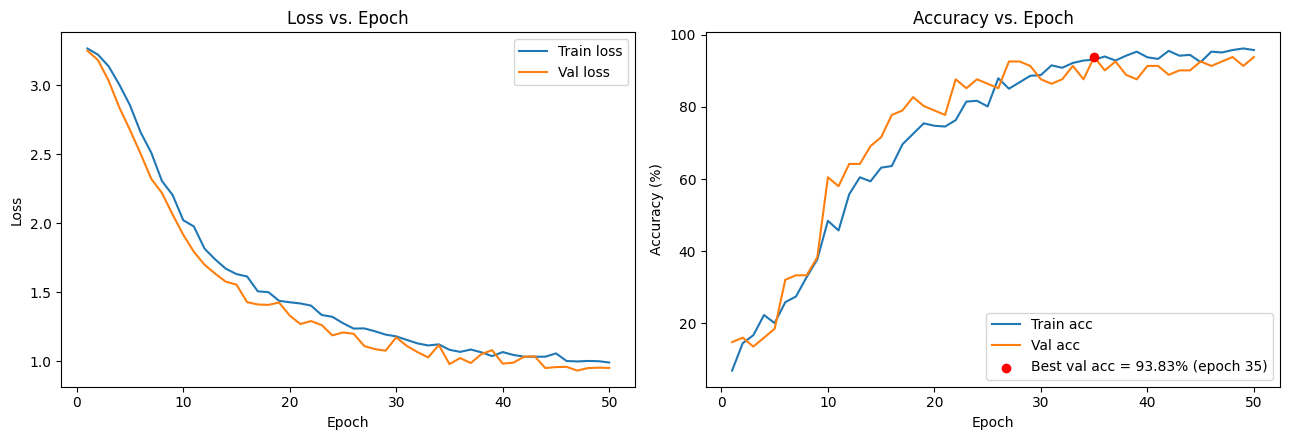

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs, history["train_loss"], label="Train loss")
axes[0].plot(epochs, history["val_loss"],   label="Val loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss vs. Epoch")
axes[0].legend()

axes[1].plot(epochs, [a*100 for a in history["train_acc"]], label="Train acc")
axes[1].plot(epochs, [a*100 for a in history["val_acc"]],   label="Val acc")
best_epoch = int(np.argmax(history["val_acc"])) + 1
best_acc   = max(history["val_acc"]) * 100
axes[1].scatter([best_epoch], [best_acc], color="red", zorder=5,
                label=f"Best val acc = {best_acc:.2f}% (epoch {best_epoch})")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy vs. Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_SAVE_PATH, "tcn_training_curves.png"), dpi=200)
plt.show()

tcn_history = history  # keep a copy for the TCN-vs-BiLSTM comparison plot later

## BiLSTM Model

In [18]:
class BiLSTMActionRecognizer(nn.Module):
    def __init__(
        self,
        num_classes:  int,
        input_dim:    int = 236,
        proj_dim:     int = 128,
        hidden_dim:   int = 256,
        num_layers:   int = 2,
        num_heads:    int = 4,
        attn_dropout: float = 0.1,
        lstm_dropout: float = 0.3,
        head_dropout: float = 0.4,
    ):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, proj_dim),
            nn.ReLU(),
        )

        self.bilstm = nn.LSTM(
            input_size=proj_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=lstm_dropout if num_layers > 1 else 0.0,
        )

        self.proj = nn.Linear(hidden_dim * 2, proj_dim)

        self.attn = nn.MultiheadAttention(
            embed_dim=proj_dim,
            num_heads=num_heads,
            dropout=attn_dropout,
            batch_first=True,
        )

        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, 128),
            nn.ReLU(),
            nn.Dropout(head_dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.input_proj(x)
        x, _ = self.bilstm(x)
        x = self.proj(x)

        attn_out, _ = self.attn(x, x, x)
        x = x + attn_out

        x = x.mean(dim=1)
        return self.classifier(x)

In [19]:
def count_parameters(model: nn.Module, trainable_only: bool = True) -> int:
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())


def model_summary(model: nn.Module) -> None:
    total     = count_parameters(model, trainable_only=False)
    trainable = count_parameters(model, trainable_only=True)
    print("=" * 52)
    print(f"  Model          : {model.__class__.__name__}")
    print(f"  Total params   : {total:,}")
    print(f"  Trainable      : {trainable:,}")
    print(f"  Non-trainable  : {total - trainable:,}")
    print("=" * 52)

In [20]:
class EarlyStopping:
    def __init__(
        self,
        patience:  int   = 10,
        min_delta: float = 1e-4,
        mode:      str   = "min",
        verbose:   bool  = True,
    ) -> None:
        self.patience   = patience
        self.min_delta  = min_delta
        self.mode       = mode
        self.verbose    = verbose
        self.counter    = 0
        self.best_score: Optional[float] = None
        self.early_stop = False

    def __call__(self, score: float) -> bool:
        if self.best_score is None:
            self.best_score = score
            return False

        improved = (
            score < self.best_score - self.min_delta if self.mode == "min"
            else score > self.best_score + self.min_delta
        )

        if improved:
            self.best_score = score
            self.counter    = 0
        else:
            self.counter += 1
            if self.verbose:
                print(f"    EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

In [21]:
def train_one_epoch(
    model:     nn.Module,
    loader:    DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    scaler:    GradScaler,
    device:    torch.device,
    grad_clip: float = 1.0,
) -> dict:
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    t0 = time.perf_counter()

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=device.type):
            logits = model(inputs)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * inputs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += inputs.size(0)

    elapsed = time.perf_counter() - t0
    return {
        "loss":            total_loss / total,
        "accuracy":        correct / total,
        "samples_per_sec": total / elapsed,
    }

In [22]:
@torch.no_grad()
def validate(
    model:     nn.Module,
    loader:    DataLoader,
    criterion: nn.Module,
    device:    torch.device,
) -> dict:
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(device_type=device.type):
            logits = model(inputs)
            loss   = criterion(logits, labels)

        total_loss += loss.item() * inputs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += inputs.size(0)

    return {
        "loss":     total_loss / total,
        "accuracy": correct / total,
    }

In [23]:
def train(
    model:           nn.Module,
    train_loader:    DataLoader,
    val_loader:      DataLoader,
    *,
    num_classes:     int,
    num_epochs:      int   = 100,
    lr:              float = 3e-4,
    weight_decay:    float = 1e-4,
    grad_clip:       float = 1.0,
    label_smoothing: float = 0.1,
    class_weights:   Optional[torch.Tensor] = None,
    patience:        int   = 15,
    checkpoint_path: str   = "best_bilstm.pt",
    device:          Optional[torch.device] = None,
) -> dict:
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device)
    model_summary(model)
    print(f"  Device: {device}\n")

    if class_weights is not None:
        class_weights = class_weights.to(device)
    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=label_smoothing,
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
        betas=(0.9, 0.999),
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=lr * 1e-2,
    )

    scaler     = GradScaler(device="cuda" if device.type == "cuda" else "cpu")
    early_stop = EarlyStopping(patience=patience, mode="max", verbose=True)

    history    = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0

    hdr = f"{'Epoch':>6} | {'TrLoss':>8} | {'TrAcc':>7} | {'VaLoss':>8} | {'VaAcc':>7} | {'LR':>9}"
    print(hdr)
    print("-" * len(hdr))

    for epoch in range(1, num_epochs + 1):
        tr = train_one_epoch(model, train_loader, optimizer,
                             criterion, scaler, device, grad_clip)
        va = validate(model, val_loader, criterion, device)
        scheduler.step()
        lr_now = scheduler.get_last_lr()[0]

        history["train_loss"].append(tr["loss"])
        history["train_acc"].append(tr["accuracy"])
        history["val_loss"].append(va["loss"])
        history["val_acc"].append(va["accuracy"])

        print(f"{epoch:>6} | {tr['loss']:>8.4f} | {tr['accuracy']:>6.2%} | "
              f"{va['loss']:>8.4f} | {va['accuracy']:>6.2%} | {lr_now:>9.2e}")

        if va["accuracy"] > best_val_acc:
            best_val_acc = va["accuracy"]
            torch.save({
                "epoch":              epoch,
                "model_state_dict":   model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc":            best_val_acc,
                "classes":            train_loader.dataset.dataset.classes
                                      if hasattr(train_loader.dataset, "dataset") else [],
            }, checkpoint_path)

        if early_stop(va["accuracy"]):
            print(f"\n  Early stopping at epoch {epoch}.")
            break

    print(f"\n  Best val accuracy: {best_val_acc:.2%}  →  '{checkpoint_path}'")
    return history

In [24]:
@torch.no_grad()
def predict_from_path_bilstm(
    npy_path:        str,
    checkpoint_path: str,
    classes:         list[str],
    num_classes:     Optional[int] = None,
    device:          Optional[torch.device] = None,
) -> dict:
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if num_classes is None:
        num_classes = len(classes)

    ckpt  = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model = BiLSTMActionRecognizer(
        num_classes=num_classes,
        input_dim=236,
        proj_dim=128,
        hidden_dim=128,
        num_layers=2,
        num_heads=4,
        attn_dropout=0.1,
        lstm_dropout=0.2,
        head_dropout=0.4,
    )
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device).eval()

    arr = np.load(npy_path).astype(np.float32)          # (172, 59, 3)
    arr = arr[:, :, :2]                                 # (172, 59, 2)
    vel = np.zeros_like(arr)
    vel[1:] = arr[1:] - arr[:-1]
    arr = np.concatenate([arr, vel], axis=-1)           # (172, 59, 4)
    pos = arr[:, :, :2]
    mu  = pos.mean(axis=(0, 1), keepdims=True)
    std = pos.std(axis=(0, 1), keepdims=True) + 1e-6
    arr[:, :, :2] = (pos - mu) / std
    seq    = arr.reshape(172, -1)                       # (172, 236)
    tensor = torch.from_numpy(seq).unsqueeze(0).to(device)

    with autocast(device_type=device.type):
        logits = model(tensor)

    probs = F.softmax(logits, dim=-1).squeeze(0)
    top3_vals, top3_idxs = probs.topk(min(3, num_classes))
    top3 = [
        {"class": classes[i.item()], "idx": i.item(), "confidence": round(v.item(), 4)}
        for v, i in zip(top3_vals, top3_idxs)
    ]

    return {
        "predicted_class": top3[0]["class"],
        "predicted_idx":   top3[0]["idx"],
        "confidence":      top3[0]["confidence"],
        "top3":            top3,
        "all_probs":       {classes[i]: round(probs[i].item(), 4) for i in range(num_classes)},
    }

In [25]:

model_bilstm = BiLSTMActionRecognizer(
    num_classes  = NUM_CLASSES,
    input_dim    = 236,
    proj_dim     = 128,
    hidden_dim   = 512,
    num_layers   = 4,
    num_heads    = 4,
    attn_dropout = 0.1,
    lstm_dropout = 0.2,
    head_dropout = 0.3,
)

_dummy = torch.randn(2, 172, 236)
assert model_bilstm(_dummy).shape == (2, NUM_CLASSES), "Shape mismatch!"
print(f"Forward-pass check passed: (2, 172, 236) → (2, {NUM_CLASSES})")

history_bilstm = train(
    model_bilstm,
    train_loader,
    val_loader,
    num_classes     = NUM_CLASSES,
    num_epochs      = 100,
    lr              = 1e-3,
    weight_decay    = 1e-4,
    grad_clip       = 0.5,
    label_smoothing = 0.1,
    class_weights   = class_weights,
    patience        = 15,
    checkpoint_path = "models/saved/best_bilstm.pt",
    device          = DEVICE,
)

Forward-pass check passed: (2, 172, 236) → (2, 26)
  Model          : BiLSTMActionRecognizer
  Total params   : 21,776,026
  Trainable      : 21,776,026
  Non-trainable  : 0
  Device: cuda

 Epoch |   TrLoss |   TrAcc |   VaLoss |   VaAcc |        LR
------------------------------------------------------------
     1 |   3.2824 |  4.46% |   3.2743 |  3.70% |  1.00e-03
     2 |   3.2357 |  5.80% |   3.2073 |  6.17% |  9.99e-04
     3 |   3.1092 |  8.48% |   2.9465 | 11.11% |  9.98e-04
     4 |   2.9320 | 10.49% |   2.8436 |  6.17% |  9.96e-04
    EarlyStopping counter: 1/15
     5 |   2.7203 | 14.06% |   2.6119 | 13.58% |  9.94e-04
     6 |   2.6284 | 18.08% |   2.4801 | 16.05% |  9.91e-04
     7 |   2.5630 | 18.30% |   2.4592 | 22.22% |  9.88e-04
     8 |   2.5795 | 18.08% |   2.3699 | 24.69% |  9.84e-04
     9 |   2.4616 | 20.76% |   2.2171 | 38.27% |  9.80e-04
    10 |   2.3487 | 25.45% |   2.2149 | 28.40% |  9.76e-04
    EarlyStopping counter: 1/15
    11 |   2.2967 | 24.33% |   2.2

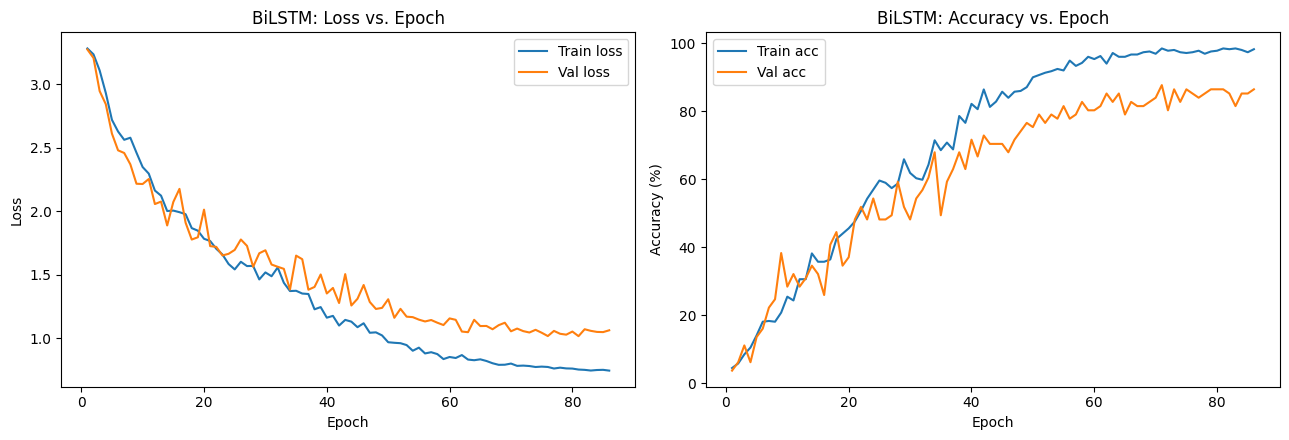

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_b = range(1, len(history_bilstm["train_loss"]) + 1)

axes[0].plot(epochs_b, history_bilstm["train_loss"], label="Train loss")
axes[0].plot(epochs_b, history_bilstm["val_loss"],   label="Val loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("BiLSTM: Loss vs. Epoch")
axes[0].legend()

axes[1].plot(epochs_b, [a*100 for a in history_bilstm["train_acc"]], label="Train acc")
axes[1].plot(epochs_b, [a*100 for a in history_bilstm["val_acc"]],   label="Val acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("BiLSTM: Accuracy vs. Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_SAVE_PATH, "bilstm_training_curves.png"), dpi=200)
plt.show()

bilstm_history = history_bilstm  # keep a copy for the comparison plot below


## Evaluation

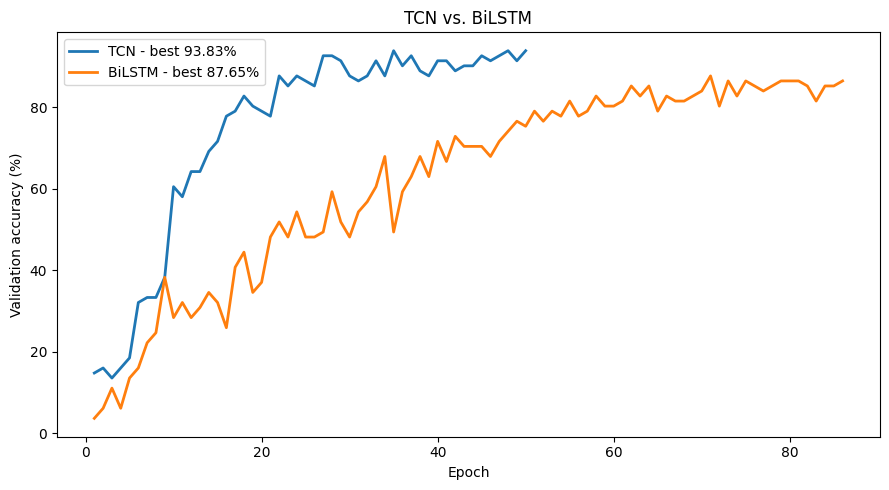

TCN params    : 503,130
BiLSTM params : 21,776,026  (43.3x larger)
TCN best val acc    : 93.83%
BiLSTM best val acc : 87.65%


In [27]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(range(1, len(tcn_history["val_acc"]) + 1),
        [a*100 for a in tcn_history["val_acc"]],
        label=f"TCN - best {max(tcn_history['val_acc'])*100:.2f}%",
        linewidth=2)
ax.plot(range(1, len(bilstm_history["val_acc"]) + 1),
        [a*100 for a in bilstm_history["val_acc"]],
        label=f"BiLSTM - best {max(bilstm_history['val_acc'])*100:.2f}%",
        linewidth=2)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation accuracy (%)")
ax.set_title("TCN vs. BiLSTM")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_SAVE_PATH, "tcn_vs_bilstm.png"), dpi=200)
plt.show()

print(f"TCN params    : 503,130")
print(f"BiLSTM params : 21,776,026  ({21776026/503130:.1f}x larger)")
print(f"TCN best val acc    : {max(tcn_history['val_acc'])*100:.2f}%")
print(f"BiLSTM best val acc : {max(bilstm_history['val_acc'])*100:.2f}%")


In [28]:
@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    classes: list[str],
    device: Optional[torch.device] = None,
) -> dict:
    """
    Full evaluation pass with per-class metrics.

    Args:
        model   : Trained TCNActionRecognizer.
        loader  : DataLoader for the evaluation set.
        classes : Ordered list of class names.
        device  : Target device. Auto-detected if None.

    Returns:
        dict with keys:
            accuracy        (float)       – overall accuracy
            avg_loss        (float)       – average cross-entropy loss
            class_report    (dict)        – per-class precision, recall, f1, support
            confusion_matrix (np.ndarray) – (num_classes, num_classes)
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_classes = len(classes)
    criterion   = nn.CrossEntropyLoss()

    model.to(device).eval()

    all_preds  = []
    all_labels = []
    total_loss = 0.0
    total      = 0

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(device_type=device.type, enabled=device.type == "cuda"):
            logits = model(inputs)
            loss   = criterion(logits, labels)

        total_loss += loss.item() * inputs.size(0)
        total      += inputs.size(0)

        all_preds.append(logits.argmax(dim=1).cpu())
        all_labels.append(labels.cpu())

    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # ── Overall accuracy ───────────────────────────────────────────────────
    accuracy = (all_preds == all_labels).float().mean().item()

    # ── Confusion matrix ───────────────────────────────────────────────────
    confusion = np.zeros((num_classes, num_classes), dtype=np.int64)
    for true, pred in zip(all_labels.tolist(), all_preds.tolist()):
        confusion[true][pred] += 1

    # ── Per-class precision, recall, F1 ───────────────────────────────────
    class_report = {}
    for i, cls in enumerate(classes):
        tp = confusion[i, i]
        fp = confusion[:, i].sum() - tp
        fn = confusion[i, :].sum() - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = (2 * precision * recall / (precision + recall)
                     if (precision + recall) > 0 else 0.0)

        class_report[cls] = {
            "precision": round(precision, 4),
            "recall":    round(recall,    4),
            "f1":        round(f1,        4),
            "support":   int(confusion[i, :].sum()),
        }

    # ── Print summary ──────────────────────────────────────────────────────
    print(f"\n{'='*58}")
    print(f"  Overall accuracy : {accuracy:.2%}")
    print(f"  Average loss     : {total_loss / total:.4f}")
    print(f"{'='*58}")
    print(f"  {'Class':<20} {'Prec':>6} {'Rec':>6} {'F1':>6} {'N':>5}")
    print(f"  {'-'*47}")
    for cls, m in class_report.items():
        print(f"  {cls:<20} {m['precision']:>6.2%} {m['recall']:>6.2%} "
              f"{m['f1']:>6.2%} {m['support']:>5}")
    print(f"{'='*58}\n")

    return {
        "accuracy":         accuracy,
        "avg_loss":         round(total_loss / total, 4),
        "class_report":     class_report,
        "confusion_matrix": confusion,
    }

In [29]:
eval_model = TCNActionRecognizer(
    num_classes  = NUM_CLASSES,
    input_dim    = 236,
    proj_dim     = 128,
    kernel_size  = 3,
    dilations    = (1, 2, 4, 8),
    num_heads    = 4,
    attn_dropout = 0.1,
    tcn_dropout  = 0.2,
    head_dropout = 0.4,
)
eval_model = load_checkpoint(os.path.join(MODEL_SAVE_PATH, "best_tcn.pt"),
                              eval_model, device=DEVICE)

results = evaluate(eval_model, val_loader, classes=full_dataset.classes, device=DEVICE)

cm_df = pd.DataFrame(
    results["confusion_matrix"],
    index=full_dataset.classes,
    columns=full_dataset.classes,
)
cm_df.to_csv(os.path.join(FIG_SAVE_PATH, "confusion_matrix.csv"))
cm_df


Loaded checkpoint 'models/saved/best_tcn.pt' (epoch 35, val_acc=93.83%)

  Overall accuracy : 93.83%
  Average loss     : 0.3522
  Class                  Prec    Rec     F1     N
  -----------------------------------------------
  1-Ardhpatka          80.00% 100.00% 88.89%     4
  10-Katakamukha       100.00% 100.00% 100.00%     3
  11-Suchi             100.00% 100.00% 100.00%     3
  12-Chandrakala       100.00% 100.00% 100.00%     3
  13-Padmakosh         80.00% 100.00% 88.89%     4
  14-Sarpashirsha      100.00% 50.00% 66.67%     2
  15-Mrigashirsha      100.00% 66.67% 80.00%     3
  16-Simhamukha        75.00% 100.00% 85.71%     3
  17-Kangula           66.67% 100.00% 80.00%     2
  18-Alapadma          100.00% 100.00% 100.00%     3
  19-Chatura           100.00% 50.00% 66.67%     2
  2-Kartarimukh        100.00% 75.00% 85.71%     4
  20-Bhramara          100.00% 100.00% 100.00%     3
  21-Hamsasya          100.00% 100.00% 100.00%     3
  22-Hamsapkshaka      100.00% 100.00% 100.00

,1-Ardhpatka,10-Katakamukha,11-Suchi,12-Chandrakala,13-Padmakosh,14-Sarpashirsha,15-Mrigashirsha,16-Simhamukha,17-Kangula,18-Alapadma,...,24-Mukula,25-Taamrachuda,26-Trishula,3-Mayura,4-Aardhchandra,5-Aarala,6-Shukatundaka,7-Mushti,8-Shikara,9-Kapitha
1-Ardhpatka,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10-Katakamukha,0,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11-Suchi,0,0,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12-Chandrakala,0,0,0,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13-Padmakosh,0,0,0,0,4,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14-Sarpashirsha,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15-Mrigashirsha,0,0,0,0,0,0,2,1,0,0,...,0,0,0,0,0,0,0,0,0,0
16-Simhamukha,0,0,0,0,0,0,0,3,0,0,...,0,0,0,0,0,0,0,0,0,0
17-Kangula,0,0,0,0,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
18-Alapadma,0,0,0,0,0,0,0,0,0,3,...,0,0,0,0,0,0,0,0,0,0


Macro-avg precision: 0.9494
Macro-avg recall   : 0.9263
Macro-avg F1        : 0.9241


,precision,recall,f1,support
14-Sarpashirsha,1.0000,0.5000,0.6667,2.0
19-Chatura,1.0000,0.5000,0.6667,2.0
17-Kangula,0.6667,1.0000,0.8000,2.0
15-Mrigashirsha,1.0000,0.6667,0.8000,3.0
9-Kapitha,0.6667,1.0000,0.8000,2.0
3-Mayura,1.0000,0.6667,0.8000,3.0
16-Simhamukha,0.7500,1.0000,0.8571,3.0
2-Kartarimukh,1.0000,0.7500,0.8571,4.0
13-Padmakosh,0.8000,1.0000,0.8889,4.0
1-Ardhpatka,0.8000,1.0000,0.8889,4.0


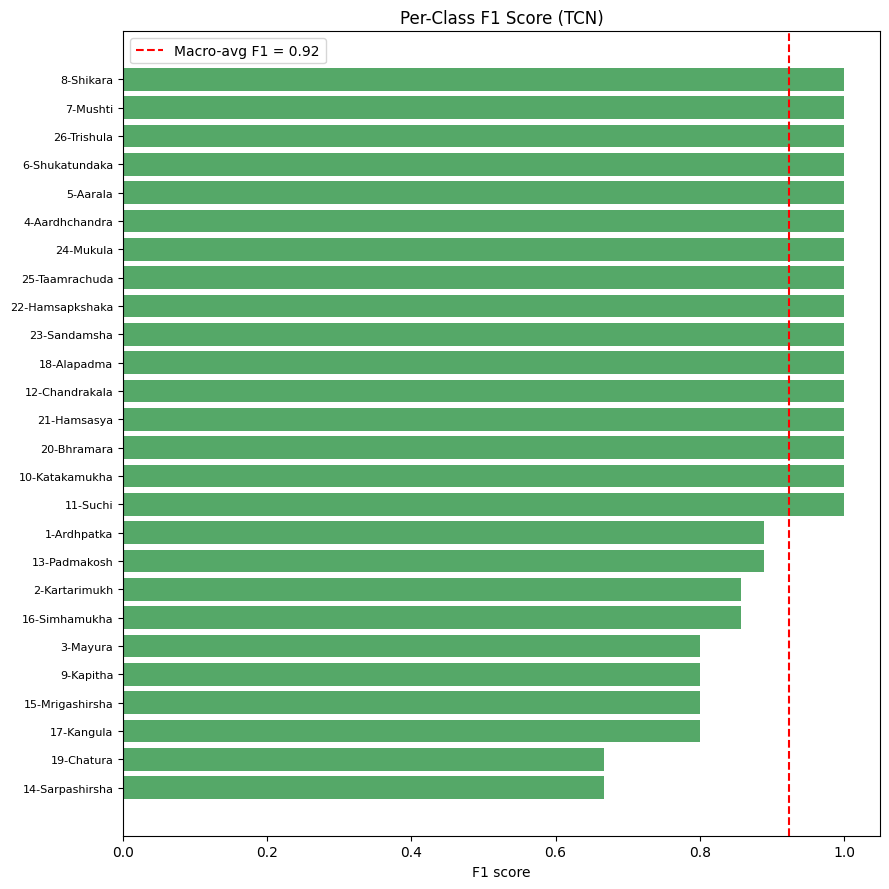

In [30]:
report_df = pd.DataFrame(results["class_report"]).T
report_df = report_df[["precision", "recall", "f1", "support"]].sort_values("f1")
report_df.to_csv(os.path.join(FIG_SAVE_PATH, "per_class_metrics.csv"))

print(f"Macro-avg precision: {report_df['precision'].mean():.4f}")
print(f"Macro-avg recall   : {report_df['recall'].mean():.4f}")
print(f"Macro-avg F1        : {report_df['f1'].mean():.4f}")
display(report_df)

fig, ax = plt.subplots(figsize=(9, 9))
y = range(len(report_df))
ax.barh(y, report_df["f1"], color="#55A868")
ax.set_yticks(y); ax.set_yticklabels(report_df.index, fontsize=8)
ax.set_xlabel("F1 score")
ax.set_title("Per-Class F1 Score (TCN)")
ax.axvline(report_df["f1"].mean(), color="red", linestyle="--",
           label=f"Macro-avg F1 = {report_df['f1'].mean():.2f}")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_SAVE_PATH, "fig_per_class_f1.png"), dpi=200)
plt.show()


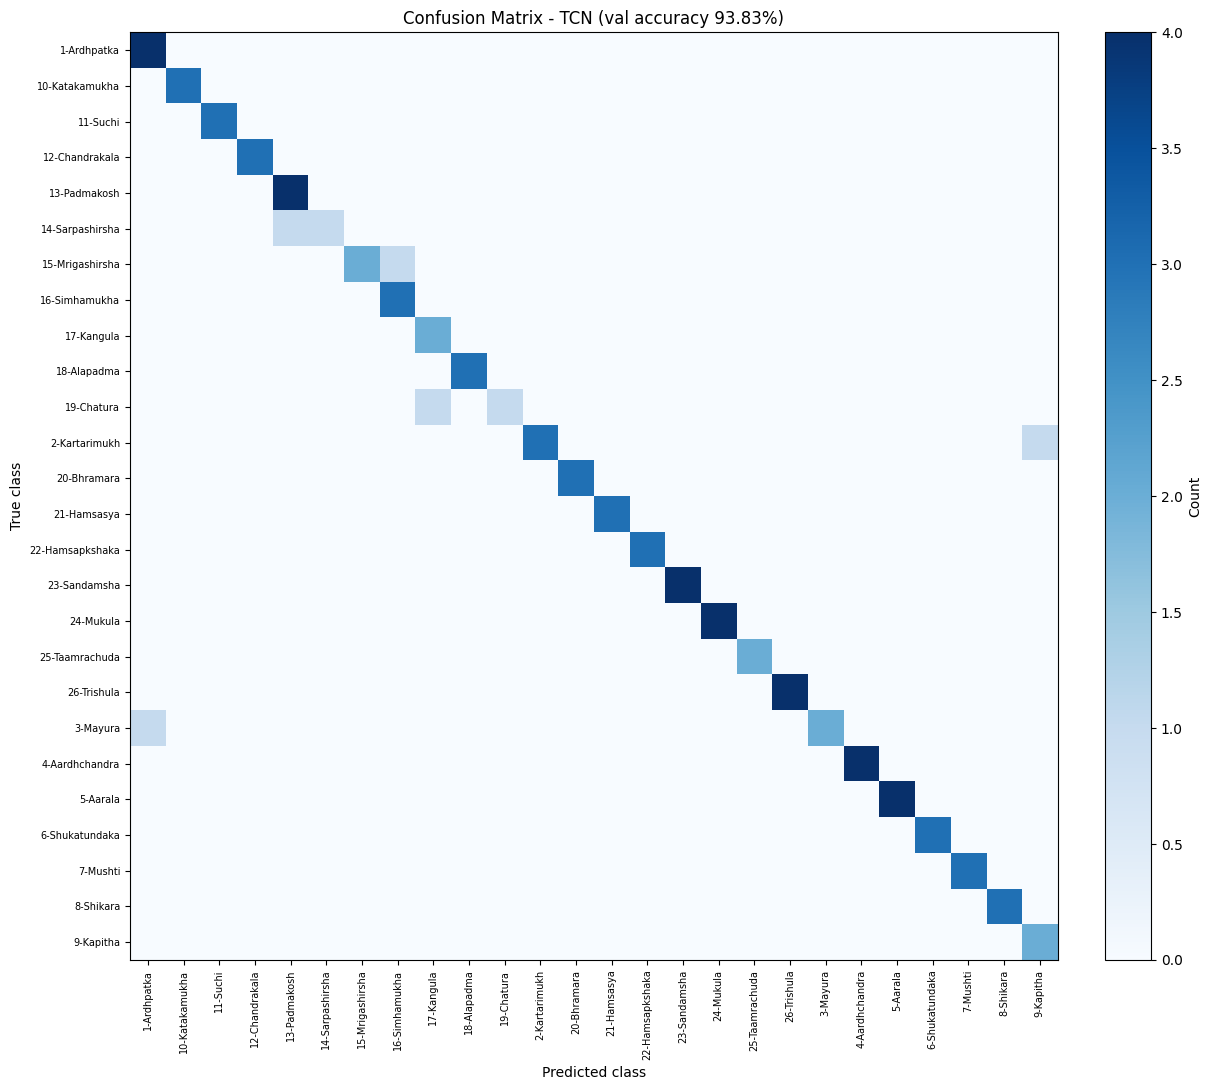

Top confused (true -> predicted) pairs:
  14-Sarpashirsha      -> 13-Padmakosh         : 1 clip(s)
  15-Mrigashirsha      -> 16-Simhamukha        : 1 clip(s)
  19-Chatura           -> 17-Kangula           : 1 clip(s)
  2-Kartarimukh        -> 9-Kapitha            : 1 clip(s)
  3-Mayura             -> 1-Ardhpatka          : 1 clip(s)


In [31]:
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(results["confusion_matrix"], cmap="Blues")

ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(full_dataset.classes, rotation=90, fontsize=7)
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(full_dataset.classes, fontsize=7)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title(f"Confusion Matrix - TCN (val accuracy {results['accuracy']*100:.2f}%)")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Count")
plt.tight_layout()
plt.savefig(os.path.join(FIG_SAVE_PATH, "fig_confusion_matrix.png"), dpi=200)
plt.show()

# Top confused class pairs (off-diagonal), useful for the Discussion section
cm = results["confusion_matrix"].copy()
np.fill_diagonal(cm, 0)
pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cm[i, j] > 0:
            pairs.append((full_dataset.classes[i], full_dataset.classes[j], int(cm[i, j])))
pairs.sort(key=lambda x: -x[2])
print("Top confused (true -> predicted) pairs:")
for true_c, pred_c, n in pairs[:10]:
    print(f"  {true_c:<20} -> {pred_c:<20} : {n} clip(s)")
